In [1]:
import numpy as np
from matplotlib import pyplot as plt

import torch

import cv2

import os
from Dataset.data import DataPath
from Dataset.DataSetLoaders.ChessDataset import ChessDataset, GameDataset

import importlib
import ChessLens
importlib.reload(ChessLens);

In [2]:
# ds = ChessDataset(
#     config={
#         "img_size": (640,640)
#     }
# )
ds = GameDataset(
    config={
        "img_size": (640,640)
    }
)
img, y = ds[70]

# img = ChessLens.ChessLensImage(os.path.join(DataPath, 'data_manual/1741715439429.jpg'))
# img = ChessLens.ChessLensImage(os.path.join(DataPath, 'data_manual/1741715439470.jpg'))
img = ChessLens.ChessLensImage(img, "cnn")
y["image_path"]

/mnt/D/University/Thesis/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mnt/D/University/Thesis/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


'/mnt/D/University/Thesis_Dataset/Games/Tryouts_Game/game_70.JPG'

In [3]:
img.detect_board()
# img.recognize_clock()
img.recognize_pieces()
img.save_fen_image()

'1r2nN2/2N3P1/1K5b/2n4k/2B1P3/4P1PK/1p4P1/1R3P2'

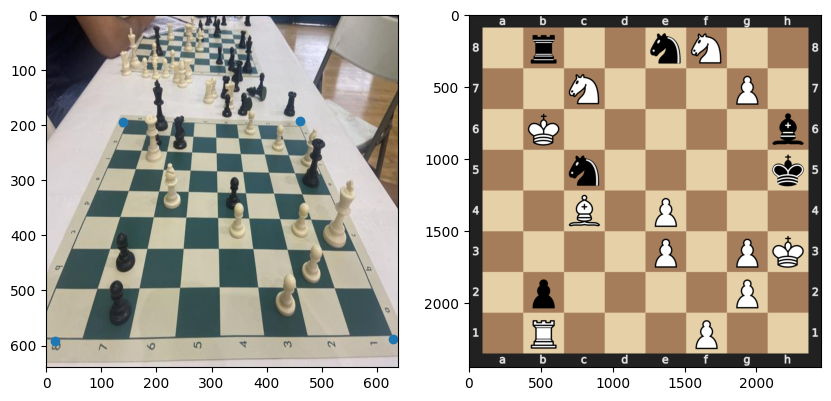

In [4]:
plt.figure(figsize=(10, 10))

plt.subplot(1,2,1)
plt.imshow(img.img.permute(1,2,0));
plt.scatter(img.board_detection[:,0], img.board_detection[:,1]);
plt.subplot(1,2,2)
plt.imshow(plt.imread("out_fen.png"));
img.fen